# SpMV kernel version comparison

Compares the three multicore SpMV kernels on the same set of matrices:

| version | kernel | bench | csv |
|---|---|---|---|
| `multicore` | `run_spmv` | `spmv` | `bench_results_spmv_128_fp16.csv` |
| `multicube` | `run_spmv_multi_cube` | `spmv_multi_cube` | `bench_results_spmv_multi_cube_128_fp16.csv` |
| `spmv_v2` | `run_spmv_v2` | `spmv_v2` | `bench_results_spmv_v2_128_fp16.csv` |

Generate the data with:
```bash
make -f Makefile.spmv.mk profile_fp16_spmv_versions
```
By default the CSVs are written to the current directory (`TCUSCAN_BENCHMARK_REPORT_PATH`
defaults to `.`), which is what `benchmarks_dir` below points at. Set both to a
different directory if you want to keep runs separate.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

benchmarks_dir = "../.."

# (glob pattern, version label). The patterns are mutually exclusive:
# *spmv_128* does not match spmv_multi_cube_128 nor spmv_v2_128.
version_globs = [
    ("*spmv_128*.csv", "multicore"),
    ("*spmv_multi_cube_128*.csv", "multicube"),
    ("*spmv_v2_128_fp16.csv", "spmv_v2"),
    ("*spmv_ops_sparse_fp16.csv", "spmv_ops_sparse"),
    ]

dfs = []
for pattern, version in version_globs:
    files = glob(join(benchmarks_dir, pattern))
    if not files:
        print(f"WARNING: no files match {pattern}")
        continue
    df = pd.concat(map(pd.read_csv, files))
    df["version"] = version
    dfs.append(df)

grand_df = pd.concat(dfs)
grand_df = grand_df.sort_values(by=["nnz", "version"])
grand_df.head(20)

,benchname,operator,dtype,nnz,nrow,time_us,version
2,enron,spmv_128,fp16,276143,69245.0,297.39,multicore
2,enron,spmv_multi_cube_128,fp16,276143,69245.0,277.35,multicube
1,enron,spmv_ops_sparse,fp16,276143,NaN,2511.30,spmv_ops_sparse
2,enron,spmv_v2_128,fp16,276143,69245.0,790.38,spmv_v2
15,me2010,spmv_128,fp16,335476,69519.0,302.85,multicore
15,me2010,spmv_multi_cube_128,fp16,335476,69519.0,290.04,multicube
12,me2010,spmv_ops_sparse,fp16,335476,NaN,1540.19,spmv_ops_sparse
15,me2010,spmv_v2_128,fp16,335476,69519.0,598.40,spmv_v2
6,bcircuit,spmv_128,fp16,375558,68903.0,307.66,multicore
6,bcircuit,spmv_multi_cube_128,fp16,375558,68903.0,297.94,multicube


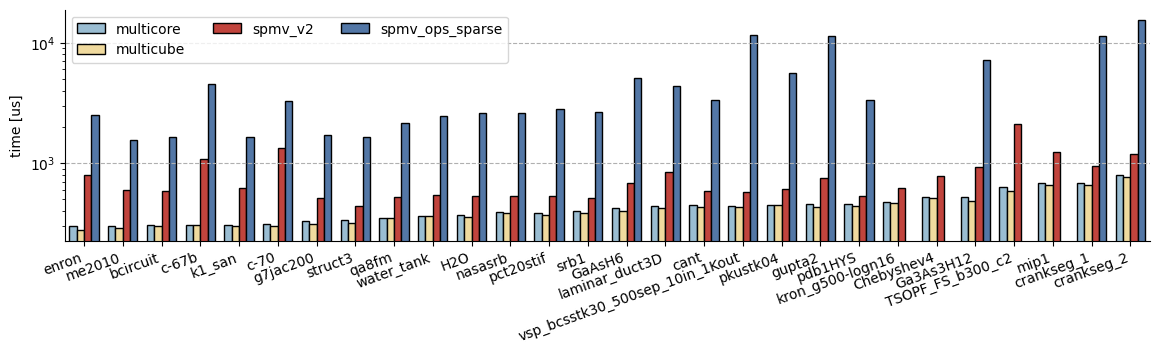

In [20]:
# Per-matrix bar chart: time [us], one bar per version.
palette = ["#91bfdb", "#fee090", "#d73027", "#4575b4"]

plt.figure(figsize=(14, 3))
ax = sns.barplot(
    data=grand_df,
    x="benchname",
    y="time_us",
    hue="version",
    hue_order=["multicore", "multicube", "spmv_v2", "spmv_ops_sparse"],
    edgecolor="black",
    palette=palette,
    estimator="median",
    width=0.75,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(linestyle="--", axis="y")
plt.legend(loc="upper left", ncol=3)
plt.xticks(rotation=20, ha="right")
plt.xlabel("")
plt.ylabel("time [us]")
plt.yscale("log")
plt.savefig("spmv_versions_comparison.pdf", bbox_inches="tight")

In [21]:
# Speedup of each version relative to the spmv_v2 baseline, per matrix.
med = grand_df.groupby(["benchname", "version"])["time_us"].median().unstack()
speedup = med.div(med["spmv_v2"], axis=0)
speedup = speedup.rename(columns=lambda c: f"{c}_x_over_spmv_v2")
speedup.sort_values("spmv_ops_sparse_x_over_spmv_v2", ascending=False).head(20)

version,multicore_x_over_spmv_v2,multicube_x_over_spmv_v2,spmv_ops_sparse_x_over_spmv_v2,spmv_v2_x_over_spmv_v2
benchname,,,,
vsp_bcsstk30_500sep_10in_1Kout,0.771118,0.757617,20.225192,1.0
gupta2,0.609257,0.584892,15.256471,1.0
crankseg_2,0.671885,0.651576,13.047332,1.0
crankseg_1,0.722929,0.703199,12.122440,1.0
pkustk04,0.737245,0.739105,9.213611,1.0
Ga3As3H12,0.563717,0.528496,7.818531,1.0
GaAsH6,0.618388,0.586976,7.379418,1.0
pdb1HYS,0.858558,0.833043,6.321696,1.0
cant,0.764480,0.729489,5.670016,1.0
